# Mass Properties & Bill of Materials
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

Compute the **rigid-body mass properties** of the sized vehicle and produce a
**conceptual Bill of Materials (BOM)** — the last handoff the 6-DoF simulation
(Aetherion) needs before the airframe can fly:

| Output | Consumer |
|--------|----------|
| Total mass \(m\), CG position \(\mathbf{r}_{CG}\) | 6-DoF EOM, `vbat_aero.dml` reference point |
| Inertia tensor \(\mathbf{I}_{CG}\) (body FRD) | 6-DoF EOM, control-authority sizing (NB3 \(\ddot\theta = M/I\)) |
| Principal moments & radii of gyration | sanity checks, handling-qualities estimates |
| `out/bom.csv`, `out/mass_properties.yaml` | procurement, Aetherion / DAVE-ML handoff |

Everything is driven by the **upstream design state** — nothing is hard-coded:

| Input | Source |
|-------|--------|
| Component masses & stations | `out/fuselage.yaml` `layout` (NB4 packing solution) |
| Fuselage meridian \(r(x_s)\) | `fuselage_design.fuselage_radius` (same function as NB4/NB5) |
| Wing span, chord, \(t/c\) | mass closure re-run + `config/wing_structure_params.yaml` |
| Duct / vane geometry | `out/fuselage.yaml`, `out/control_vanes.yaml` (NB3) |

## Axis convention (Aetherion)

Body **FRD** — \(x\) forward (out the nose), \(y\) right, \(z\) down.
Fuselage **stations** \(x_s\) are measured from the nose tip, **positive aft**:
\(x_{body} = -x_s\).  All components sit on the body \(x\)-axis in this
conceptual model, so the CG lies on the axis and the products of inertia
vanish (vane/leg/strut asymmetries are second-order and carried inside the
`misc` fraction).

---

In [1]:
import sys, math
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "font.size"         : 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83",
     "#5aae61", "#9970ab", "#e08214", "#35978f"]

FIG_DIR = Path("figures")   # per-notebook figures directory
FIG_DIR.mkdir(exist_ok=True)


# Section 1 — Design Inputs

Re-run the sizing loop from `config/` — same pattern as NB2–NB5, so this
notebook stays consistent with the upstream design state — and load the
geometry/packing handoffs written by the previous notebooks.

---

In [2]:
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics
from conceptual_design.fuselage_design import fuselage_radius

env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")

result = run_sizing_loop(
    m_payload_kg = mission.payload_kg,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = rotor.D_rotor_m,
    P_hotel_W    = avionics.P_hotel_W,
)

with open(OUT_PATH / "fuselage.yaml") as f:
    fus = yaml.safe_load(f)
with open(OUT_PATH / "control_vanes.yaml") as f:
    vanes = yaml.safe_load(f)
with open(OUT_PATH / "airfoil.yaml") as f:
    af = yaml.safe_load(f)
with open(CONFIG_PATH / "fuselage.yaml") as f:
    fus_cfg = yaml.safe_load(f)

b_wing_m     = result.wing.b_wing
chord_wing_m = result.wing.chord_mean
t_wing_m     = ws.tc_ratio * chord_wing_m

D_fus, L_fus = fus["D_fus_m"], fus["L_fus_m"]
R_int        = D_fus / 2.0 - fus_cfg["t_shell_m"]     # internal bay radius
pack         = fus_cfg["packing_factor"]

layout = {c["name"]: c for c in fus["layout"]}
m_layout = sum(c["mass_kg"] for c in fus["layout"])

print(f"MTOW (mass closure)   : {result.m_total_kg:.4f} kg")
print(f"MTOW (NB4 layout sum) : {m_layout:.4f} kg")
print(f"Fuselage              : D = {D_fus*1e3:.1f} mm, L = {L_fus*1e3:.1f} mm")
print(f"Wing                  : {af['designation']}, b = {b_wing_m*1e3:.0f} mm, "
      f"c = {chord_wing_m*1e3:.1f} mm, t = {t_wing_m*1e3:.1f} mm")
print(f"Duct                  : {fus['D_duct_inner_m']*1e3:.0f} / "
      f"{fus['D_duct_outer_m']*1e3:.0f} mm, chord {fus['duct_chord_m']*1e3:.0f} mm")
print(f"Axis convention       : {fus['axis_convention']}")

MTOW (mass closure)   : 2.1021 kg
MTOW (NB4 layout sum) : 2.1020 kg
Fuselage              : D = 128.8 mm, L = 644.0 mm
Wing                  : NACA 2412, b = 1002 mm, c = 167.0 mm, t = 20.0 mm
Duct                  : 286 / 302 mm, chord 126 mm
Axis convention       : body FRD (x fwd, y right, z down); stations from nose, +aft; x_body = -station


# Section 2 — Inertia Primitives

Each component is idealised as an axisymmetric primitive centred on the body
\(x\)-axis, with inertia known in closed form **about its own CG** (axes
parallel to body FRD).  With everything on the axis, only the diagonal terms
survive and \(I_{yy} = I_{zz}\) for every primitive except the wing plate.

**Solid cylinder** (axis along \(x\), radius \(r\), length \(L\)) — dense bays
(battery, payload, avionics, ESC, motor):

$$
I_{xx} = \tfrac12 m r^2, \qquad
I_{yy} = I_{zz} = \tfrac{1}{12} m \left(3r^2 + L^2\right)
$$

**Thin-walled tube** (duct annulus, mean radius \(r\), length \(L\)):

$$
I_{xx} = m r^2, \qquad
I_{yy} = I_{zz} = m\left(\tfrac{r^2}{2} + \tfrac{L^2}{12}\right)
$$

**Rectangular plate** (wing: span \(b\) along \(y\), chord \(c\) along \(x\),
thickness \(t\) along \(z\)):

$$
I_{xx} = \tfrac{m}{12}\!\left(b^2 + t^2\right),\quad
I_{yy} = \tfrac{m}{12}\!\left(c^2 + t^2\right),\quad
I_{zz} = \tfrac{m}{12}\!\left(b^2 + c^2\right)
$$

**Thin shell of revolution** (fuselage monocoque) — the *same* meridian
\(r(x_s)\) used by NB4 sizing and the NB5 CAD revolve, integrated numerically
with area density \(\sigma\).  For a hoop of width
\(\mathrm{d}s = \sqrt{1 + r'^2}\,\mathrm{d}x\):

$$
\mathrm{d}m = \sigma\, 2\pi r\, \mathrm{d}s, \qquad
\mathrm{d}I_{xx} = r^2\,\mathrm{d}m, \qquad
\mathrm{d}I_{yy}\big|_{ring} = \tfrac{r^2}{2}\,\mathrm{d}m
$$

\(\sigma\) is scaled so the integrated mass matches the NB4
`shell_struct` budget (shell + frames + carry-through, \(k_{struct}\)
included).  Transverse terms are shifted to the shell CG with the parallel
axis theorem, and the whole stack is assembled about the vehicle CG the same
way:

$$
\mathbf{I}_{CG}^{veh} \;=\; \sum_i \Big[ \mathbf{I}_{CG,i}
 \;+\; m_i \big( d_i^2\,\mathbf{E} - \mathbf{d}_i \mathbf{d}_i^{\!\top} \big) \Big],
 \qquad \mathbf{d}_i = \mathbf{r}_i - \mathbf{r}_{CG}
$$

---

In [3]:
@dataclass
class Component:
    """Rigid component on the body x-axis.

    x_s   : CG station from nose, +aft [m]  (body x = -x_s)
    I_cg  : (Ixx, Iyy, Izz) about own CG, axes parallel to body FRD [kg m^2]
    """
    name:     str
    mass_kg:  float
    x_s:      float
    I_cg:     tuple
    primitive: str


def solid_cylinder(name, m, x_s, r, L):
    Ixx = 0.5 * m * r**2
    Itr = m * (3.0 * r**2 + L**2) / 12.0
    return Component(name, m, x_s, (Ixx, Itr, Itr), "solid cylinder")


def thin_tube(name, m, x_s, r_mean, L):
    Ixx = m * r_mean**2
    Itr = m * (r_mean**2 / 2.0 + L**2 / 12.0)
    return Component(name, m, x_s, (Ixx, Itr, Itr), "thin tube")


def flat_plate_wing(name, m, x_s, b, c, t):
    Ixx = m * (b**2 + t**2) / 12.0
    Iyy = m * (c**2 + t**2) / 12.0
    Izz = m * (b**2 + c**2) / 12.0
    return Component(name, m, x_s, (Ixx, Iyy, Izz), "flat plate")


def shell_of_revolution(name, m, x_cg_layout, D, L, f_nose, f_tail, r_hub, n=800):
    """Thin monocoque shell using the NB4/NB5 meridian, scaled to mass m.

    The meridian integration provides the *shape* (second moments about the
    shell's own CG); the CG station itself is pinned to the NB4 layout value
    so the vehicle-level mass bookkeeping closes exactly.  (The layout CG
    includes the k_struct frames/carry-through allocation, which the bare
    skin integral does not know about.)
    """
    x  = np.linspace(0.0, L, n + 1)
    r  = np.array([fuselage_radius(xi, D, L, f_nose, f_tail, r_hub) for xi in x])
    dr = np.gradient(r, x)
    ds = np.sqrt(1.0 + dr**2)                    # arc-length factor
    w  = 2.0 * np.pi * r * ds                    # dA/dx  (sigma = 1)

    A      = np.trapezoid(w, x)                  # total area  -> sigma = m/A
    x_cg   = np.trapezoid(w * x, x) / A          # skin-only CG (shape)
    Ixx    = (m / A) * np.trapezoid(w * r**2, x)
    Iyy_0  = (m / A) * np.trapezoid(w * (r**2 / 2.0 + x**2), x)   # about nose
    Iyy_cg = Iyy_0 - m * x_cg**2                 # parallel axis -> shell CG
    return Component(name, m, x_cg_layout, (Ixx, Iyy_cg, Iyy_cg),
                     "shell of revolution")


def radial_cluster(name, m_each, n, x_s, d, primitive="radial cluster"):
    """n identical point masses at radius d, distributed symmetrically
    about the body x-axis at station x_s (vanes, servos, linkages).

    For a symmetric set (e.g. n = 4 at T/B/L/R):
        Ixx = n m d^2,   Iyy = Izz = (n/2) m d^2
    Products of inertia cancel by symmetry.
    """
    m = n * m_each
    Ixx = m * d**2
    Itr = 0.5 * m * d**2
    return Component(name, m, x_s, (Ixx, Itr, Itr), primitive)


def assemble(components):
    """Total mass, CG station, and inertia tensor about the CG (body FRD)."""
    m_tot = sum(c.mass_kg for c in components)
    x_cg  = sum(c.mass_kg * c.x_s for c in components) / m_tot
    I = np.zeros((3, 3))
    for c in components:
        d = c.x_s - x_cg                         # offset along x only
        I += np.diag(c.I_cg)
        I += c.mass_kg * np.diag([0.0, d**2, d**2])   # parallel axis
    return m_tot, x_cg, I

print("Primitives defined: solid_cylinder, thin_tube, flat_plate_wing, "
      "shell_of_revolution, assemble")

Primitives defined: solid_cylinder, thin_tube, flat_plate_wing, shell_of_revolution, assemble


# Section 3 — Component Mass Model

Map each entry of the NB4 packing `layout` to a primitive.  Masses and CG
stations come **verbatim** from `out/fuselage.yaml` — this notebook adds only
the *shape* assumption needed for second moments:

| Layout entry | Primitive | Geometry assumption |
|---|---|---|
| `payload`, `avionics`, `battery`, `esc` | solid cylinder | bay length from layout; \(r_{eff} = \sqrt{\eta_{pack}}\,R_{int}\) so the cylinder volume equals the packed component volume |
| `motor_fan` | solid cylinder | \(r = r_{hub}\), \(L = 60\) mm (motor can + fan disc) |
| `duct` | thin tube | mean radius of the annulus, length = duct chord |
| `shell_struct` | shell of revolution | NB4 meridian (shape); CG pinned to the layout station, which includes the \(k_{struct}\) frames allocation |
| `wing` | flat plate | \(b \times c \times t\) from mass closure + \(t/c\) |
| **vanes** (4×) | radial cluster | carved out of `misc`; CFRP plate \(S_{vane} \times t_{plate}\), at \(R_{mid}\) on the NB3 station |
| **servos** (4×) | radial cluster | carved out of `misc`; 9g-class case + horn + wiring, recessed in the centerbody hub with the shaft on the hinge line — matching the NB5 CAD placement |
| **linkages/hinges** (4×) | radial cluster | carved out of `misc`; pushrod + hinge pin per vane |
| `misc` (remainder) | solid cylinder | harness, fasteners, bonding, margin; \(r = R_{int}/2\), \(L = L_{fus}/2\) at the layout CG |

The control hardware is placed exactly where NB3 sized it and where the NB5
solid model mounts it: vane mid-span at \(R_{mid}\), vane station `x_vane_m`;
servos at the hinge line \(x_{hinge} = x_{vane,TE} - (1 - x_{hinge}/c)\,c_{vane}\),
CG inside the hub.  Because the `misc` allocation keeps the *station* it had
in NB4, moving hardware aft to the vanes shifts the vehicle CG slightly aft —
this notebook reports that shift against the NB4 handoff rather than
asserting equality.

**Servo selection check** — NB3 requires
\(\tau_{servo} \ge\) `servo_torque_req_gcm` per vane; a 9g-class servo
(≈ 1800 g·cm at 4.8 V) is verified against that below.

---

In [4]:
r_eff = math.sqrt(pack) * R_int          # preserves packed component volume

# ---- control hardware, carved out of the NB4 `misc` allocation ---------
RHO_CFRP    = 1600.0                     # laminate density [kg/m^3]
T_PLATE_MIN = 0.002                      # min manufacturable plate [m] (NB5)

n_vanes      = vanes["n_vanes"]
m_vane_each  = vanes["S_vane_m2"] * T_PLATE_MIN * RHO_CFRP     # CFRP flat plate
m_servo_each = 0.012                     # 9g-class servo + horn + wiring [kg]
m_link_each  = 0.003                     # pushrod + hinge pin per vane   [kg]

servo_torque_avail_gcm = 1800.0          # 9g-class at 4.8 V (e.g. SG90)
tau_req = vanes["servo_torque_req_gcm"]
print(f"Servo torque check : need {tau_req:.0f} g-cm/vane, "
      f"9g-class gives ~{servo_torque_avail_gcm:.0f} g-cm "
      f"-> margin {servo_torque_avail_gcm/tau_req:.1f}x  "
      f"{'OK' if servo_torque_avail_gcm > tau_req else 'FAIL'}")

m_ctl_total = n_vanes * (m_vane_each + m_servo_each + m_link_each)
m_misc_rem  = layout["misc"]["mass_kg"] - m_ctl_total
assert m_misc_rem > 0, "misc allocation cannot absorb the control hardware"
print(f"Control hardware   : {n_vanes} x (vane {m_vane_each*1e3:.1f} g + "
      f"servo {m_servo_each*1e3:.0f} g + linkage {m_link_each*1e3:.0f} g) "
      f"= {m_ctl_total*1e3:.1f} g")
print(f"misc remainder     : {m_misc_rem*1e3:.1f} g "
      f"(was {layout['misc']['mass_kg']*1e3:.1f} g)")

# stations & radii, matching the NB5 CAD placement
x_vane_te  = fus["x_vane_m"] + 0.5 * vanes["c_vane_m"]
x_hinge    = x_vane_te - (1.0 - vanes["hinge_xc"]) * vanes["c_vane_m"]
r_servo_cg = vanes["R_hub_m"] - 0.022 + 0.027 / 2.0   # recessed case mid-height

components = [
    solid_cylinder("payload",  layout["payload"]["mass_kg"],
                   layout["payload"]["x_cg_m"],  r_eff, layout["payload"]["length_m"]),
    solid_cylinder("avionics", layout["avionics"]["mass_kg"],
                   layout["avionics"]["x_cg_m"], r_eff, layout["avionics"]["length_m"]),
    solid_cylinder("battery",  layout["battery"]["mass_kg"],
                   layout["battery"]["x_cg_m"],  r_eff, layout["battery"]["length_m"]),
    solid_cylinder("esc",      layout["esc"]["mass_kg"],
                   layout["esc"]["x_cg_m"],      r_eff, layout["esc"]["length_m"]),
    solid_cylinder("motor_fan", layout["motor_fan"]["mass_kg"],
                   layout["motor_fan"]["x_cg_m"], fus["r_hub_m"], 0.060),
    thin_tube("duct", layout["duct"]["mass_kg"], layout["duct"]["x_cg_m"],
              (fus["D_duct_inner_m"] + fus["D_duct_outer_m"]) / 4.0,
              fus["duct_chord_m"]),
    shell_of_revolution("shell_struct", layout["shell_struct"]["mass_kg"],
                        layout["shell_struct"]["x_cg_m"],
                        D_fus, L_fus, fus["f_nose"], fus["f_tail"], fus["r_hub_m"]),
    flat_plate_wing("wing", layout["wing"]["mass_kg"], layout["wing"]["x_cg_m"],
                    b_wing_m, chord_wing_m, t_wing_m),
    radial_cluster("vanes (4x)",    m_vane_each,  n_vanes,
                   fus["x_vane_m"], vanes["R_mid_m"], "radial cluster"),
    radial_cluster("servos (4x)",   m_servo_each, n_vanes,
                   x_hinge, r_servo_cg, "radial cluster"),
    radial_cluster("linkages (4x)", m_link_each,  n_vanes,
                   x_hinge, vanes["R_hub_m"], "radial cluster"),
    solid_cylinder("misc (rem.)", m_misc_rem,
                   layout["misc"]["x_cg_m"], R_int / 2.0, L_fus / 2.0),
]

print(f"{'component':<14}{'primitive':<22}{'m [kg]':>8}{'x_s [mm]':>10}"
      f"{'Ixx':>12}{'Iyy':>12}{'Izz':>12}   [kg m^2, about own CG]")
print("-" * 92)
for c in components:
    print(f"{c.name:<14}{c.primitive:<22}{c.mass_kg:>8.4f}{c.x_s*1e3:>10.1f}"
          f"{c.I_cg[0]:>12.3e}{c.I_cg[1]:>12.3e}{c.I_cg[2]:>12.3e}")

Servo torque check : need 556 g-cm/vane, 9g-class gives ~1800 g-cm -> margin 3.2x  OK
Control hardware   : 4 x (vane 6.5 g + servo 12 g + linkage 3 g) = 86.1 g
misc remainder     : 61.0 g (was 147.1 g)
component     primitive               m [kg]  x_s [mm]         Ixx         Iyy         Izz   [kg m^2, about own CG]
--------------------------------------------------------------------------------------------
payload       solid cylinder          0.5000      76.4   6.067e-04   5.833e-04   5.833e-04
avionics      solid cylinder          0.1682     137.4   2.041e-04   1.246e-04   1.246e-04
battery       solid cylinder          0.4459     177.0   5.411e-04   3.270e-04   3.270e-04
esc           solid cylinder          0.0788     322.0   9.562e-05   5.832e-05   5.832e-05
motor_fan     solid cylinder          0.1892     595.7   2.967e-04   2.051e-04   2.051e-04
duct          thin tube               0.0473     614.6   1.022e-03   5.736e-04   5.736e-04
shell_struct  shell of revolution     0.423

# Section 4 — Vehicle CG and Inertia Tensor

Assemble the stack about the vehicle CG.  Checks and findings:

1. total mass must equal the mass-closure MTOW (hard assert),
2. off-diagonal terms must be zero — the vane/servo clusters are symmetric
   about the axis (hard assert),
3. the CG is **compared** against the NB4 handoff `x_CG_m`.  NB4 lumped the
   control hardware into `misc` at \(0.4\,L_{fus}\); pulling ~86 g of vanes,
   servos and linkages aft to their true stations moves the vehicle CG aft
   and **erodes the static margin** — quantified below against the NB4
   target.  This is the feedback this notebook exists to provide: the next
   NB4 iteration should re-balance the packing (battery forward) to recover
   the margin.

---

In [5]:
m_tot, x_cg_s, I_cg = assemble(components)

r_cg_body = np.array([-x_cg_s, 0.0, 0.0])            # FRD, origin at nose tip
Ixx, Iyy, Izz = np.diag(I_cg)
k = np.sqrt(np.diag(I_cg) / m_tot)                   # radii of gyration

dx_cg    = x_cg_s - fus["x_CG_m"]                    # refined - NB4 handoff
SM_nb4   = fus["static_margin"]
SM_ref   = (fus["x_wing_AC_m"] - x_cg_s) / chord_wing_m   # rectangular: MAC = c

print(f"Total mass            : {m_tot:.4f} kg   "
      f"(mass closure {result.m_total_kg:.4f} kg)")
print(f"CG station x_s        : {x_cg_s*1e3:.2f} mm from nose")
print(f"  NB4 handoff         : {fus['x_CG_m']*1e3:.2f} mm  "
      f"-> refined CG is {dx_cg*1e3:+.1f} mm "
      f"({'aft' if dx_cg > 0 else 'fwd'}) of the NB4 estimate")
print(f"Static margin         : {SM_ref:+.3f} MAC  "
      f"(NB4 target {SM_nb4:+.3f})")
if SM_ref < 0.0:
    print("  *** CG is AFT of the wing AC -> statically unstable in cruise.")
    print("  *** Feed back to NB4: shift battery/payload forward or move the")
    print("  *** wing aft, then re-run NB4 -> NB6.")
elif SM_ref < SM_nb4:
    print("  ->  margin eroded vs. target; re-balance packing in NB4.")
print(f"CG body-frame r_CG    : [{r_cg_body[0]:.5f}, 0, 0] m  (FRD, nose origin)")
print()
print("Inertia tensor about CG, body FRD [kg m^2]:")
with np.printoptions(precision=5, suppress=True):
    print(I_cg)
print()
print(f"  Ixx (roll)  = {Ixx:.5f} kg m^2   k_x = {k[0]*1e3:.1f} mm")
print(f"  Iyy (pitch) = {Iyy:.5f} kg m^2   k_y = {k[1]*1e3:.1f} mm")
print(f"  Izz (yaw)   = {Izz:.5f} kg m^2   k_z = {k[2]*1e3:.1f} mm")
print(f"  Iyy/Ixx     = {Iyy/Ixx:.1f}  -> slender tail-sitter: pitch/yaw dominated")

assert abs(m_tot - m_layout) < 1e-6, "mass bookkeeping broken"
assert np.allclose(I_cg, np.diag(np.diag(I_cg))), "unexpected products of inertia"
print("\nMass closure and symmetry checks passed.")

Total mass            : 2.1020 kg   (mass closure 2.1021 kg)
CG station x_s        : 250.84 mm from nose
  NB4 handoff         : 234.02 mm  -> refined CG is +16.8 mm (aft) of the NB4 estimate
Static margin         : -0.051 MAC  (NB4 target +0.050)
  *** CG is AFT of the wing AC -> statically unstable in cruise.
  *** Feed back to NB4: shift battery/payload forward or move the
  *** wing aft, then re-run NB4 -> NB6.
CG body-frame r_CG    : [-0.25084, 0, 0] m  (FRD, nose origin)

Inertia tensor about CG, body FRD [kg m^2]:
[[0.0133  0.      0.     ]
 [0.      0.08186 0.     ]
 [0.      0.      0.09036]]

  Ixx (roll)  = 0.01330 kg m^2   k_x = 79.5 mm
  Iyy (pitch) = 0.08186 kg m^2   k_y = 197.3 mm
  Izz (yaw)   = 0.09036 kg m^2   k_z = 207.3 mm
  Iyy/Ixx     = 6.2  -> slender tail-sitter: pitch/yaw dominated

Mass closure and symmetry checks passed.


# Section 5 — Visualization

Left: component CGs on the fuselage side profile (marker area ∝ mass), with
the vehicle CG and the wing AC from NB4 — the gap between them *is* the 5 %
static margin.  Right: where each moment of inertia actually comes from
(own-CG term + parallel-axis transport term).

---

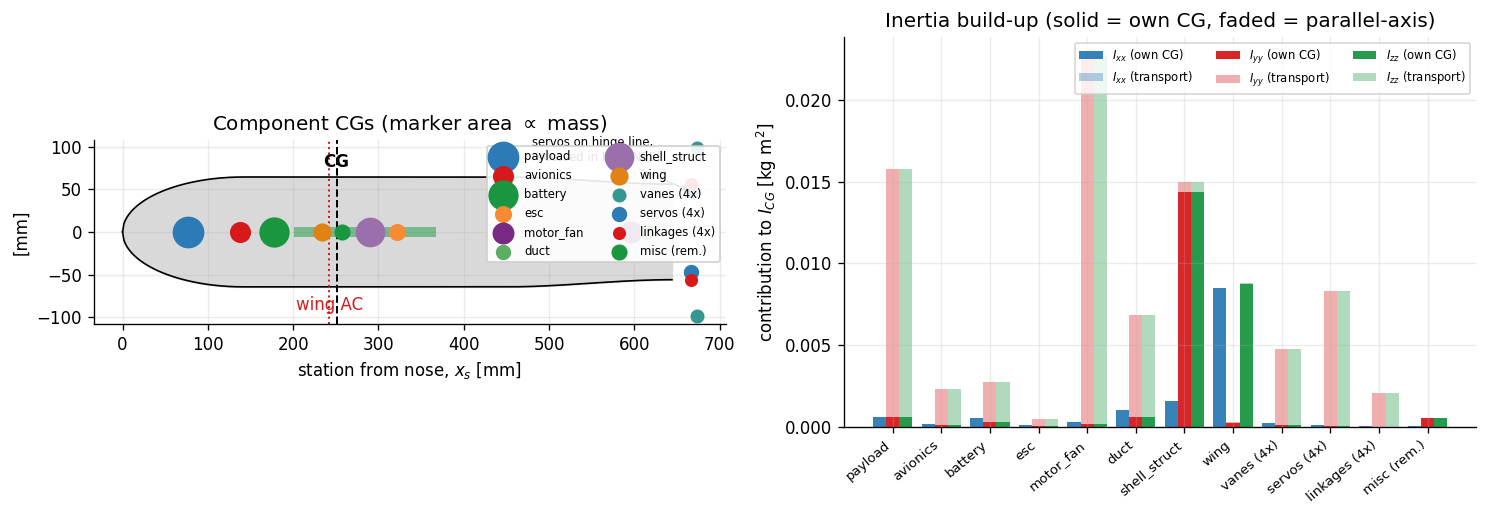

Largest Iyy contributors:
  motor_fan     0.0227 kg m^2 (28 %)
  payload       0.0158 kg m^2 (19 %)
  shell_struct  0.0150 kg m^2 (18 %)
  servos (4x)   0.0083 kg m^2 (10 %)


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

# --- side profile with CG markers -------------------------------------
xs = np.linspace(0.0, L_fus, 400)
rs = np.array([fuselage_radius(x, D_fus, L_fus, fus["f_nose"],
                               fus["f_tail"], fus["r_hub_m"]) for x in xs])
ax1.fill_between(xs * 1e3, -rs * 1e3, rs * 1e3, color="0.85", zorder=1)
ax1.plot(xs * 1e3,  rs * 1e3, "k-", lw=1)
ax1.plot(xs * 1e3, -rs * 1e3, "k-", lw=1)

# wing chord line at its station
x_le = fus["x_wing_LE_m"]
ax1.plot([x_le * 1e3, (x_le + chord_wing_m) * 1e3], [0, 0],
         color=C[2], lw=6, alpha=0.5, solid_capstyle="butt", zorder=2)

# clusters plot at their true radial offset (mirrored), on-axis parts at r=0
r_plot = {"vanes (4x)": vanes["R_mid_m"], "servos (4x)": r_servo_cg,
          "linkages (4x)": vanes["R_hub_m"]}
for i, c in enumerate(components):
    r_off = r_plot.get(c.name, 0.0)
    s = 40 + 1200 * c.mass_kg / m_tot
    ax1.scatter(c.x_s * 1e3,  r_off * 1e3, s=s, color=C[i % len(C)],
                zorder=3, label=c.name)
    if r_off > 0:
        ax1.scatter(c.x_s * 1e3, -r_off * 1e3, s=s, color=C[i % len(C)],
                    zorder=3)
ax1.annotate("servos on hinge line,\nrecessed in hub (NB5)",
             (x_hinge * 1e3, r_servo_cg * 1e3), xytext=(-95, 18),
             textcoords="offset points", fontsize=7,
             arrowprops=dict(arrowstyle="->", lw=0.8))

ax1.axvline(x_cg_s * 1e3, color="k", ls="--", lw=1.2)
ax1.annotate("CG", (x_cg_s * 1e3, D_fus / 2 * 1e3), xytext=(0, 6),
             textcoords="offset points", ha="center", fontweight="bold")
ax1.axvline(fus["x_wing_AC_m"] * 1e3, color=C[1], ls=":", lw=1.2)
ax1.annotate("wing AC", (fus["x_wing_AC_m"] * 1e3, -D_fus / 2 * 1e3),
             xytext=(0, -14), textcoords="offset points", ha="center",
             color=C[1])
ax1.set_xlabel("station from nose, $x_s$ [mm]")
ax1.set_ylabel("[mm]")
ax1.set_title("Component CGs (marker area $\\propto$ mass)")
ax1.set_aspect("equal")
ax1.legend(loc="upper right", fontsize=7, ncol=2, framealpha=0.9)

# --- inertia breakdown -------------------------------------------------
names  = [c.name for c in components]
own    = np.array([c.I_cg for c in components])              # (n, 3)
transp = np.array([[0.0,
                    c.mass_kg * (c.x_s - x_cg_s)**2,
                    c.mass_kg * (c.x_s - x_cg_s)**2] for c in components])

x = np.arange(len(names))
w = 0.27
for j, (axis, col) in enumerate(zip(["$I_{xx}$", "$I_{yy}$", "$I_{zz}$"],
                                    [C[0], C[1], C[2]])):
    ax2.bar(x + (j - 1) * w, own[:, j],   w, color=col, alpha=0.95,
            label=axis + " (own CG)" if True else None)
    ax2.bar(x + (j - 1) * w, transp[:, j], w, bottom=own[:, j],
            color=col, alpha=0.35,
            label=axis + " (transport)" )
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
ax2.set_ylabel("contribution to $I_{CG}$ [kg m$^2$]")
ax2.set_title("Inertia build-up (solid = own CG, faded = parallel-axis)")
ax2.legend(fontsize=7, ncol=3)

fig.tight_layout()
fig.savefig(OUT_PATH / "mass_properties.png", bbox_inches="tight")
plt.show()

print("Largest Iyy contributors:")
tot_yy = own[:, 1] + transp[:, 1]
for i in np.argsort(tot_yy)[::-1][:4]:
    print(f"  {names[i]:<14}{tot_yy[i]:.4f} kg m^2 "
          f"({100 * tot_yy[i] / Iyy:.0f} %)")

# Section 6 — Bill of Materials

Conceptual-level BOM.  Line items follow the NB4 mass budget exactly (so the
`total mass` column sums to MTOW), with the NB3 control-vane hardware and the
landing gear broken out as **indented sub-items whose mass is carried inside
the `misc` / structure fractions** — they get real masses once components are
selected.  Part numbers use `VBT-<CAT>-NNN`
(STR structure, PRP propulsion, PWR power, AVI avionics, PLD payload,
CTL controls, GEA gear).

---

In [7]:
rows = [
 # part_no        item                          qty  material / spec        unit_kg  x_cg_mm
 ("VBT-STR-001", "Fuselage monocoque shell",     1, "CFRP 2-ply, 0.8 mm + frames (k_struct)",
  layout["shell_struct"]["mass_kg"], layout["shell_struct"]["x_cg_m"]*1e3),
 ("VBT-STR-002", "Wing, constant chord",         1, f"CFRP skin/foam core, {af['designation']}",
  layout["wing"]["mass_kg"], layout["wing"]["x_cg_m"]*1e3),
 ("VBT-PRP-001", "EDF motor + fan rotor",        1, f"D = {rotor.D_rotor_m*1e3:.0f} mm EDF, BLDC outrunner",
  layout["motor_fan"]["mass_kg"], layout["motor_fan"]["x_cg_m"]*1e3),
 ("VBT-PRP-002", "Duct / shroud annulus",        1, "CFRP wound annulus, 8 mm wall",
  layout["duct"]["mass_kg"], layout["duct"]["x_cg_m"]*1e3),
 ("VBT-PWR-001", "Battery pack",                 1, "LiPo, 140 Wh/kg pack-level",
  layout["battery"]["mass_kg"], layout["battery"]["x_cg_m"]*1e3),
 ("VBT-PWR-002", "ESC",                          1, "sized to hover power",
  layout["esc"]["mass_kg"], layout["esc"]["x_cg_m"]*1e3),
 ("VBT-AVI-001", "Avionics stack",               1, "FC + GPS + RX + telemetry",
  layout["avionics"]["mass_kg"], layout["avionics"]["x_cg_m"]*1e3),
 ("VBT-PLD-001", "Payload (EO sensor + mount)",  1, "requirement, 0.5 kg",
  layout["payload"]["mass_kg"], layout["payload"]["x_cg_m"]*1e3),
 # -- control hardware, now with real masses (carved from misc) ---------
 ("VBT-CTL-001", "Jet control vane", n_vanes,
  f"CFRP flat plate {T_PLATE_MIN*1e3:.0f} mm, c={vanes['c_vane_m']*1e3:.1f} mm, "
  f"h={vanes['h_vane_m']*1e3:.1f} mm",
  m_vane_each, fus["x_vane_m"]*1e3),
 ("VBT-CTL-002", "Vane servo, 9g-class", n_vanes,
  f"~{servo_torque_avail_gcm:.0f} g-cm >= req {tau_req:.0f} g-cm, "
  f"recessed in hub, shaft on hinge line",
  m_servo_each, x_hinge*1e3),
 ("VBT-CTL-003", "Hinge + pushrod set", n_vanes,
  "pin hinge + wire pushrod per vane",
  m_link_each, x_hinge*1e3),
 ("VBT-STR-090", "Misc: harness, fasteners, bonding, margin", 1, "allocation (remainder)",
  m_misc_rem, layout["misc"]["x_cg_m"]*1e3),
 # -- geometry carried inside the structure fraction --------------------
 ("VBT-STR-010", "Duct support strut", 4, "flat plate, min 2 mm (in k_struct)",
  None, layout["duct"]["x_cg_m"]*1e3),
 ("VBT-GEA-001", "Landing leg / skid", 4, "on duct, tail-sitter stance (in k_struct)",
  None, fus["x_vane_m"]*1e3),
]

bom = pd.DataFrame(rows, columns=["part_no", "item", "qty",
                                  "material_spec", "unit_mass_kg", "x_cg_mm"])
bom["total_mass_kg"] = bom["unit_mass_kg"] * bom["qty"]
bom["x_cg_mm"] = bom["x_cg_mm"].round(1)

m_bom = bom["total_mass_kg"].sum()
print(bom.to_string(index=False, na_rep="(in k_struct)"))
print("-" * 100)
print(f"BOM mass total : {m_bom:.4f} kg   (MTOW {m_tot:.4f} kg)")
assert abs(m_bom - m_tot) < 1e-6, "BOM does not close against MTOW"

bom.to_csv(OUT_PATH / "bom.csv", index=False)
print(f"\nWrote {OUT_PATH / 'bom.csv'}")

    part_no                                      item  qty                                                    material_spec  unit_mass_kg  x_cg_mm  total_mass_kg
VBT-STR-001                  Fuselage monocoque shell    1                           CFRP 2-ply, 0.8 mm + frames (k_struct)      0.423900    289.8       0.423900
VBT-STR-002                      Wing, constant chord    1                                   CFRP skin/foam core, NACA 2412      0.101600    234.0       0.101600
VBT-PRP-001                     EDF motor + fan rotor    1                                   D = 280 mm EDF, BLDC outrunner      0.189200    595.7       0.189200
VBT-PRP-002                     Duct / shroud annulus    1                                    CFRP wound annulus, 8 mm wall      0.047300    614.6       0.047300
VBT-PWR-001                              Battery pack    1                                       LiPo, 140 Wh/kg pack-level      0.445900    177.0       0.445900
VBT-PWR-002                 

# Section 7 — Handoff: `out/mass_properties.yaml`

Written for the Aetherion 6-DoF EOM and the DAVE-ML export
(`vbat_aero.dml` reference point).  Regenerate by re-running this notebook.

---

In [8]:
handoff = {
    "axis_convention": fus["axis_convention"],
    "m_total_kg":  float(round(m_tot, 5)),
    "x_CG_m":      float(round(x_cg_s, 5)),        # station from nose, +aft
    "x_CG_nb4_m":  float(fus["x_CG_m"]),           # NB4 estimate, for reference
    "static_margin_refined": float(round(SM_ref, 4)),
    "static_margin_nb4":     float(SM_nb4),
    "r_CG_body_m": [float(round(v, 5)) for v in r_cg_body],
    "inertia_about_CG_body_FRD": {
        "Ixx_kgm2": float(round(Ixx, 6)),
        "Iyy_kgm2": float(round(Iyy, 6)),
        "Izz_kgm2": float(round(Izz, 6)),
        "Ixy_kgm2": 0.0, "Ixz_kgm2": 0.0, "Iyz_kgm2": 0.0,
    },
    "radii_of_gyration_m": {
        "k_x": float(round(k[0], 5)),
        "k_y": float(round(k[1], 5)),
        "k_z": float(round(k[2], 5)),
    },
    "components": [
        {"name": c.name, "primitive": c.primitive,
         "mass_kg": float(round(c.mass_kg, 5)),
         "x_cg_m":  float(round(c.x_s, 5)),
         "Ixx_kgm2": float(round(c.I_cg[0], 7)),
         "Iyy_kgm2": float(round(c.I_cg[1], 7)),
         "Izz_kgm2": float(round(c.I_cg[2], 7))}
        for c in components
    ],
}

header = (
    "# AUTO-GENERATED -- do not edit by hand.\n"
    "# Source : notebooks/mass_properties.ipynb\n"
    "# Input  : out/fuselage.yaml layout + mass closure + config/\n"
    "# Regen  : re-run notebooks/mass_properties.ipynb\n"
)
with open(OUT_PATH / "mass_properties.yaml", "w") as f:
    f.write(header)
    yaml.safe_dump(handoff, f, sort_keys=False)

print(f"Wrote {OUT_PATH / 'mass_properties.yaml'}")
print(f"\n  m      = {m_tot:.4f} kg")
print(f"  r_CG   = [{r_cg_body[0]:+.4f}, 0, 0] m  (body FRD, nose origin)")
print(f"  I_CG   = diag({Ixx:.5f}, {Iyy:.5f}, {Izz:.5f}) kg m^2")

Wrote /home/claude/vbat-uav-notebooks/out/mass_properties.yaml

  m      = 2.1020 kg
  r_CG   = [-0.2508, 0, 0] m  (body FRD, nose origin)
  I_CG   = diag(0.01330, 0.08186, 0.09036) kg m^2


# Summary & Limitations

- **Mass closes exactly** against the NB4 budget — the control hardware
  (vanes, 9g-class servos, linkages) is now carried at its true aft station
  instead of inside the mid-body `misc` lump, and the servo placement matches
  the NB5 solid model (recessed in the exhaust centerbody hub, output shaft
  on the vane hinge line).
- **Key finding:** moving that hardware aft shifts the vehicle CG aft of the
  NB4 estimate and erodes the static margin.  The next design pass should
  re-balance the NB4 packing (battery/payload forward, or wing aft) and
  re-run NB4 → NB6.
- **Inertias are shape estimates.**  Axisymmetric primitives are standard at
  the conceptual stage; expect ±15–20 % on \(I_{yy}, I_{zz}\) and more on
  \(I_{xx}\) (small, dominated by duct, wing and the vane/servo clusters).
  The symmetric clusters keep the products of inertia identically zero; the
  real vehicle will have small non-zero terms.
- **Cross-check path:** the NB5 CadQuery solid (now including the four
  servos) can provide an independent uniform-density inertia check per part
  once wall thicknesses are modelled.
- **Next step:** replace the remaining fraction-based items (`avionics`,
  `esc`, `misc` remainder) with datasheet masses as hardware is selected,
  then re-run NB4 → NB6 to update CG, static margin, and the NB3
  control-authority numbers (\(\ddot\theta = M/I_{yy}\)) in one pass.
